# Kalshi Sports Bot — Backtest
**Period:** January 1 – March 25, 2026  
**Starting balance:** $10,000  
**Strategy:** Compare an independent probability model (ESPN win-rate / sportsbook odds / tennis rankings) against Kalshi pre-game prices. Trade when the gap exceeds 10 percentage points — buy YES if the model says the contract is underpriced, buy NO if overpriced. Max 4 trades per day, $10 per trade (as many contracts as $10 buys).

**Price used for backtesting:** `previous_yes_ask_dollars` / `previous_yes_bid_dollars` from each settled market — these are the prices from the trading day *before* the game settled, giving a clean pre-game snapshot without look-ahead bias.

**Caveats:**
- Team win-rates are pulled from ESPN's historical scoreboard for each game date (records as of that day in the season).
- Tennis uses current ATP/WTA rankings as a proxy (rankings shift modestly over a single season).
- Markets with no prior-day price (created same-day) are excluded.
- Fill is assumed at the ask price; real-world slippage may vary.

In [1]:
import os, re, json, time, base64, datetime, math
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

from cryptography.hazmat.primitives import serialization, hashes
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.backends import default_backend

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

/Users/benjaminthompson/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Matplotlib is building the font cache; this may take a moment.


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
KALSHI_KEY_ID   = os.environ.get('KALSHI_KEY_ID', '')
KALSHI_KEY_FILE = os.environ.get('KALSHI_KEY_FILE', '')
KALSHI_BASE     = 'https://api.elections.kalshi.com'

BACKTEST_START     = datetime.date(2026, 1, 1)
BACKTEST_END       = datetime.date(2026, 3, 25)
STARTING_BALANCE   = 10_000.00
MAX_TRADES_PER_DAY = 4
BUDGET_USD         = 10.00
MIN_EDGE_PP        = 10.0

ESPN_BASE  = 'http://site.api.espn.com/apis/site/v2/sports'
CACHE_DIR  = Path('backtest_cache')
CACHE_DIR.mkdir(exist_ok=True)

# Kalshi series → (ESPN sport, ESPN league)
SPORTS_SERIES = {
    'KXNBAGAME':  ('basketball', 'nba'),
    'KXNHLGAME':  ('hockey',     'nhl'),
    'KXWTAMATCH': ('tennis',     'wta'),
    'KXATPMATCH': ('tennis',     'atp'),
}

# ── Auth ──────────────────────────────────────────────────────────────────────
if not KALSHI_KEY_FILE:
    raise RuntimeError('Set KALSHI_KEY_FILE environment variable')
with open(KALSHI_KEY_FILE, 'rb') as _f:
    _PK = serialization.load_pem_private_key(_f.read(), password=None, backend=default_backend())

def _auth_headers(method, path):
    ts  = str(int(time.time() * 1000))
    msg = ts + method.upper() + path.split('?')[0]
    sig = _PK.sign(msg.encode(),
                   padding.PSS(mgf=padding.MGF1(hashes.SHA256()),
                               salt_length=padding.PSS.DIGEST_LENGTH),
                   hashes.SHA256())
    return {'KALSHI-ACCESS-KEY': KALSHI_KEY_ID,
            'KALSHI-ACCESS-SIGNATURE': base64.b64encode(sig).decode(),
            'KALSHI-ACCESS-TIMESTAMP': ts}

def kalshi_get(path, params=None):
    r = requests.get(KALSHI_BASE + path,
                     headers=_auth_headers('GET', path),
                     params=params, timeout=20)
    r.raise_for_status()
    return r.json()

print('Auth ready. Key ID:', KALSHI_KEY_ID[:8], '...')

Auth ready. Key ID: daf6c7c1 ...


## 1. Fetch Historical Kalshi Markets
Pull every settled single-game market for the backtest window. Results are cached to disk so subsequent runs are instant.

In [3]:
MONTH_MAP = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}

def parse_ticker_date(series, ticker):
    rest = ticker[len(series)+1:]
    m = re.match(r'^(\d{2})([A-Z]{3})(\d{2})', rest)
    if not m: return None
    try: return datetime.date(2000+int(m.group(1)), MONTH_MAP[m.group(2)], int(m.group(3)))
    except: return None

def fetch_settled_markets(series):
    cache_file = CACHE_DIR / f'kalshi_{series}.json'
    if cache_file.exists():
        with open(cache_file) as f:
            data = json.load(f)
        print(f'  {series}: {len(data)} markets (cached)')
        return data

    markets, cursor, page = [], None, 0
    while page < 35:
        params = {'status': 'settled', 'series_ticker': series, 'limit': 200}
        if cursor: params['cursor'] = cursor
        resp   = kalshi_get('/trade-api/v2/markets', params)
        batch  = resp.get('markets', [])
        for m in batch:
            d = parse_ticker_date(series, m.get('ticker', ''))
            if d and BACKTEST_START <= d <= BACKTEST_END:
                m['_series']    = series
                m['_game_date'] = d.isoformat()
                markets.append(m)
        cursor = resp.get('cursor')
        page  += 1
        if not cursor: break
        time.sleep(0.1)

    with open(cache_file, 'w') as f:
        json.dump(markets, f)
    print(f'  {series}: {len(markets)} markets fetched and cached')
    return markets

print('Fetching settled Kalshi markets...')
all_markets = []
for series in SPORTS_SERIES:
    all_markets.extend(fetch_settled_markets(series))

print(f'\nTotal settled markets in backtest window: {len(all_markets)}')

Fetching settled Kalshi markets...


  KXNBAGAME: 1196 markets fetched and cached


  KXNHLGAME: 1012 markets fetched and cached


  KXWTAMATCH: 2206 markets fetched and cached


  KXATPMATCH: 2229 markets fetched and cached

Total settled markets in backtest window: 6643


## 2. Build the Probability Model
Same logic as the live bot: ESPN sportsbook money-lines → season win-rate ratio → home-court adjustment. Tennis uses a log-rank model from ESPN's live rankings.

In [4]:
# ── ESPN helpers ──────────────────────────────────────────────────────────────
_espn_mem_cache = {}

def _record_win_pct(competitor):
    for rec in competitor.get('records', []):
        if rec.get('type') == 'total':
            m = re.match(r'^(\d+)-(\d+)', rec.get('summary', ''))
            if m:
                w, l = int(m.group(1)), int(m.group(2))
                if w+l > 0: return w/(w+l)
    return None

def _ml_to_implied(ml):
    ml = float(ml)
    return 100.0/(ml+100.0) if ml > 0 else abs(ml)/(abs(ml)+100.0)

def _parse_team_game(event, sport, league):
    comps = event.get('competitions', [])
    if not comps: return None
    comp  = comps[0]
    competitors = comp.get('competitors', [])
    if len(competitors) < 2: return None
    home = next((c for c in competitors if c.get('homeAway')=='home'), competitors[0])
    away = next((c for c in competitors if c.get('homeAway')=='away'), competitors[1])
    hn = home.get('team',{}).get('displayName','')
    an = away.get('team',{}).get('displayName','')
    if not hn or not an: return None
    for odds in comp.get('odds', []):
        hml = odds.get('homeTeamOdds',{}).get('moneyLine')
        aml = odds.get('awayTeamOdds',{}).get('moneyLine')
        if hml and aml:
            hi, ai = _ml_to_implied(hml), _ml_to_implied(aml)
            t = hi+ai
            if t > 0:
                return dict(home=hn, away=an, prob_home=hi/t, prob_away=ai/t,
                            sport=sport, league=league, source='espn_odds')
    hp, ap = _record_win_pct(home), _record_win_pct(away)
    if hp is None and ap is None: return None
    hp = hp or 0.5; ap = ap or 0.5
    t  = hp+ap
    ph = min(0.95, max(0.05, (hp/t)+0.04))
    return dict(home=hn, away=an, prob_home=ph, prob_away=1-ph,
                sport=sport, league=league, source='win_pct')

# ── Tennis rankings (fetched once) ────────────────────────────────────────────
_tennis_rankings = {}

def _load_tennis_rankings():
    global _tennis_rankings
    cache_file = CACHE_DIR / 'tennis_rankings.json'
    if cache_file.exists():
        with open(cache_file) as f:
            _tennis_rankings = json.load(f)
        print(f'  Tennis rankings loaded from cache ({len(_tennis_rankings)} players)')
        return
    for league in ('atp', 'wta'):
        try:
            r = requests.get(f'{ESPN_BASE}/tennis/{league}/rankings', timeout=10)
            r.raise_for_status()
            for grp in r.json().get('rankings', []):
                for entry in grp.get('ranks', []):
                    rank = entry.get('current')
                    name = entry.get('athlete', {}).get('displayName', '')
                    if rank and name:
                        _tennis_rankings[name] = int(rank)
        except Exception as e:
            print(f'  Warning: tennis rankings ({league}) failed: {e}')
    with open(cache_file, 'w') as f:
        json.dump(_tennis_rankings, f)
    print(f'  Tennis rankings fetched ({len(_tennis_rankings)} players)')

_load_tennis_rankings()

def _get_tennis_games(league, date_str):
    today_date = date_str[:4]+'-'+date_str[4:6]+'-'+date_str[6:]
    try:
        r = requests.get(f'{ESPN_BASE}/tennis/{league}/scoreboard',
                         params={'dates': date_str}, timeout=10)
        r.raise_for_status()
        events = r.json().get('events', [])
    except Exception:
        return []
    games = []
    for event in events:
        for group in event.get('groupings', []):
            for comp in group.get('competitions', []):
                if comp.get('date','')[:10] != today_date: continue
                competitors = comp.get('competitors', [])
                if len(competitors) < 2: continue
                p1 = competitors[0].get('athlete',{}).get('displayName','')
                p2 = competitors[1].get('athlete',{}).get('displayName','')
                if not p1 or not p2: continue
                r1 = _tennis_rankings.get(p1, 200)
                r2 = _tennis_rankings.get(p2, 200)
                l1, l2 = math.log(r1+1), math.log(r2+1)
                p_p1 = min(0.95, max(0.05, l2/(l1+l2)))
                games.append(dict(home=p1, away=p2,
                                  prob_home=p_p1, prob_away=1-p_p1,
                                  sport='tennis', league=league,
                                  source=f'rank(#{r1} vs #{r2})'))
    return games

# ── Main ESPN fetcher (with disk cache) ───────────────────────────────────────
def get_espn_games(sport, league, date_str):
    key = (sport, league, date_str)
    if key in _espn_mem_cache: return _espn_mem_cache[key]
    cache_file = CACHE_DIR / f'espn_{sport}_{league}_{date_str}.json'
    if cache_file.exists():
        with open(cache_file) as f:
            games = json.load(f)
        _espn_mem_cache[key] = games
        return games
    if league in ('wta', 'atp'):
        games = _get_tennis_games(league, date_str)
    else:
        try:
            r = requests.get(f'{ESPN_BASE}/{sport}/{league}/scoreboard',
                             params={'dates': date_str}, timeout=10)
            r.raise_for_status()
            events = r.json().get('events', [])
        except Exception:
            events = []
        games = [g for ev in events
                 for g in [_parse_team_game(ev, sport, league)] if g]
    with open(cache_file, 'w') as f:
        json.dump(games, f)
    _espn_mem_cache[key] = games
    return games

print('Model functions ready.')

  Tennis rankings fetched (300 players)
Model functions ready.


In [5]:
# ── Market matching (same logic as live bot) ──────────────────────────────────
def _words(name):
    return [w for w in re.split(r'\W+', name.lower()) if len(w) > 2]

def _overlap(text, team):
    tw = set(_words(text))
    return sum(1 for w in _words(team) if w in tw)

def match_market_to_game(market, games):
    rules    = market.get('rules_primary', '')
    title    = market.get('title', '')
    yes_sub  = market.get('yes_sub_title', '')
    full_txt = f'{rules} {title} {yes_sub}'
    series   = market.get('_series', '')
    league_f = SPORTS_SERIES.get(series, (None,None))[1]

    best, best_prob, best_score = None, None, 0
    for game in games:
        if league_f and game.get('league') != league_f: continue
        h, a = game['home'], game['away']
        hs, as_ = _overlap(full_txt, h), _overlap(full_txt, a)
        if hs == 0 or as_ == 0: continue
        yh = _overlap(yes_sub or title, h)
        ya = _overlap(yes_sub or title, a)
        if yh >= ya and yh > 0:
            prob_yes, yes_team = game['prob_home'], h
        elif ya > yh:
            prob_yes, yes_team = game['prob_away'], a
        else:
            continue
        score = hs + as_ + max(yh, ya)
        if score > best_score:
            best_score, best, best_prob = score, game, prob_yes
    if best and best_score >= 2:
        return best, best_prob
    return None, None

print('Matching functions ready.')

Matching functions ready.


## 3. Run the Backtest
For each day in the window: collect all settled markets whose game was that day, fetch ESPN model probabilities, rank opportunities by edge magnitude, simulate the top 4 trades, and record P&L.

In [6]:
# Group settled markets by game date
from collections import defaultdict
markets_by_date = defaultdict(list)
for m in all_markets:
    markets_by_date[m['_game_date']].append(m)

# ── Pre-fetch all ESPN data for dates we actually need ─────────────────────────
unique_dates = sorted(markets_by_date.keys())
print(f'Pre-fetching ESPN data for {len(unique_dates)} game dates...')
for i, date_str in enumerate(unique_dates):
    ds = date_str.replace('-', '')
    for series, (sport, league) in SPORTS_SERIES.items():
        get_espn_games(sport, league, ds)
    if (i+1) % 10 == 0:
        print(f'  {i+1}/{len(unique_dates)} dates processed...')
    time.sleep(0.05)   # be gentle with ESPN
print('ESPN data ready.')

Pre-fetching ESPN data for 84 game dates...


  10/84 dates processed...


  20/84 dates processed...


  30/84 dates processed...


  40/84 dates processed...


  50/84 dates processed...


  60/84 dates processed...


  70/84 dates processed...


  80/84 dates processed...


ESPN data ready.


In [7]:
# ── Backtest simulation ────────────────────────────────────────────────────────
trades       = []
balance      = STARTING_BALANCE
balance_hist = []

date = BACKTEST_START
while date <= BACKTEST_END:
    date_str  = date.isoformat()
    date_8    = date.strftime('%Y%m%d')
    day_markets = markets_by_date.get(date_str, [])

    # Collect all ESPN games for this date across all sports
    all_day_games = []
    for series, (sport, league) in SPORTS_SERIES.items():
        all_day_games.extend(get_espn_games(sport, league, date_8))

    # Find opportunities
    seen_events = set()
    opportunities = []
    for market in day_markets:
        event_tk = market.get('event_ticker', market['ticker'])
        if event_tk in seen_events: continue

        # Use previous-day bid/ask as the pre-game Kalshi price
        try:
            prev_ask = float(market.get('previous_yes_ask_dollars', 0) or 0)
            prev_bid = float(market.get('previous_yes_bid_dollars', 0) or 0)
        except (TypeError, ValueError):
            continue
        # Skip if no prior-day price (created same day) or already at settlement
        if prev_ask < 0.01 or prev_ask > 0.99 or prev_bid < 0.01: continue

        kalshi_mid = (prev_ask + prev_bid) / 2.0

        game, model_prob = match_market_to_game(market, all_day_games)
        if game is None or model_prob is None: continue

        edge_pp = (model_prob - kalshi_mid) * 100.0
        if abs(edge_pp) < MIN_EDGE_PP: continue

        side  = 'yes' if edge_pp > 0 else 'no'
        price = prev_ask if side == 'yes' else (1.0 - prev_bid)
        if price < 0.01 or price > 0.99: continue

        contracts = int(BUDGET_USD / price)
        if contracts < 1: continue

        result = market.get('result', '').lower()
        if result not in ('yes', 'no'): continue

        won     = (side == result)
        cost    = contracts * price
        pnl     = contracts * (1.0 - price) if won else -cost

        seen_events.add(event_tk)
        opportunities.append(dict(
            date       = date_str,
            ticker     = market['ticker'],
            title      = market.get('title', ''),
            sport      = game['sport'],
            league     = game['league'],
            home       = game['home'],
            away       = game['away'],
            source     = game['source'],
            side       = side,
            kalshi_mid = round(kalshi_mid * 100, 1),
            model_prob = round(model_prob * 100, 1),
            edge_pp    = round(edge_pp, 1),
            price      = round(price, 4),
            contracts  = contracts,
            cost       = round(cost, 2),
            result     = result,
            won        = won,
            pnl        = round(pnl, 2),
        ))

    # Take top-4 by edge magnitude
    opportunities.sort(key=lambda x: abs(x['edge_pp']), reverse=True)
    day_trades = opportunities[:MAX_TRADES_PER_DAY]

    for t in day_trades:
        balance += t['pnl']
        t['balance_after'] = round(balance, 2)
        trades.append(t)

    balance_hist.append({'date': date_str, 'balance': round(balance, 2),
                         'trades': len(day_trades)})
    date += datetime.timedelta(days=1)

df = pd.DataFrame(trades)
bal_df = pd.DataFrame(balance_hist)
bal_df['date'] = pd.to_datetime(bal_df['date'])

print(f'Backtest complete. {len(df)} trades simulated.')

Backtest complete. 27 trades simulated.


## 4. Results

In [8]:
# ── Performance summary ────────────────────────────────────────────────────────
total_pnl     = round(balance - STARTING_BALANCE, 2)
total_return  = round((balance / STARTING_BALANCE - 1) * 100, 2)
n_trades      = len(df)
n_wins        = int(df['won'].sum()) if n_trades else 0
win_rate      = round(n_wins / n_trades * 100, 1) if n_trades else 0
avg_pnl       = round(df['pnl'].mean(), 2) if n_trades else 0
total_wagered = round(df['cost'].sum(), 2) if n_trades else 0

# Drawdown
bal_series = bal_df['balance']
peak       = bal_series.cummax()
drawdown   = ((bal_series - peak) / peak * 100)
max_dd     = round(drawdown.min(), 2)

# Daily P&L for Sharpe
bal_df['daily_pnl'] = bal_df['balance'].diff().fillna(0)
std_daily = bal_df['daily_pnl'].std()
sharpe    = round((bal_df['daily_pnl'].mean() / std_daily) * (252**0.5), 2) if std_daily > 0 else 0

print('═'*52)
print(f'  BACKTEST RESULTS  ({BACKTEST_START} → {BACKTEST_END})')
print('═'*52)
print(f'  Starting balance   :  ${STARTING_BALANCE:>10,.2f}')
print(f'  Ending balance     :  ${balance:>10,.2f}')
print(f'  Total P&L          :  ${total_pnl:>+10,.2f}')
print(f'  Total return       :  {total_return:>+9.2f}%')
print('─'*52)
print(f'  Total trades       :  {n_trades:>10}')
print(f'  Wins / Losses      :  {n_wins} / {n_trades - n_wins}')
print(f'  Win rate           :  {win_rate:>9.1f}%')
print(f'  Avg P&L per trade  :  ${avg_pnl:>+9.2f}')
print(f'  Total wagered      :  ${total_wagered:>10,.2f}')
print('─'*52)
print(f'  Max drawdown       :  {max_dd:>9.2f}%')
print(f'  Sharpe ratio (ann) :  {sharpe:>9.2f}')
print('═'*52)

════════════════════════════════════════════════════
  BACKTEST RESULTS  (2026-01-01 → 2026-03-25)
════════════════════════════════════════════════════
  Starting balance   :  $ 10,000.00
  Ending balance     :  $  9,905.73
  Total P&L          :  $    -94.27
  Total return       :      -0.94%
────────────────────────────────────────────────────
  Total trades       :          27
  Wins / Losses      :  5 / 22
  Win rate           :       18.5%
  Avg P&L per trade  :  $    -3.49
  Total wagered      :  $    267.27
────────────────────────────────────────────────────
  Max drawdown       :      -1.19%
  Sharpe ratio (ann) :      -1.57
════════════════════════════════════════════════════


In [9]:
# ── Trade log ─────────────────────────────────────────────────────────────────
if len(df):
    display_cols = ['date','league','title','side',
                    'kalshi_mid','model_prob','edge_pp',
                    'contracts','cost','result','pnl','balance_after']
    disp = df[display_cols].copy()
    disp.columns = ['Date','League','Market','Side',
                    'Kalshi¢','Model%','Edge pp',
                    'Contracts','Cost $','Result','P&L $','Balance $']
    pd.set_option('display.max_rows', 60)
    pd.set_option('display.float_format', '{:.2f}'.format)
    display(disp.head(60))
else:
    print('No trades generated.')

,Date,League,Market,Side,Kalshi¢,Model%,Edge pp,Contracts,Cost $,Result,P&L $,Balance $
0,2026-01-26,nba,Philadelphia at Charlotte Winner?,yes,27.50,52.90,25.40,35,9.80,no,-9.80,9990.20
1,2026-01-27,nba,Sacramento at New York Winner?,yes,10.50,25.10,14.60,90,9.90,no,-9.90,9980.30
2,2026-01-27,nba,Portland at Washington Winner?,no,51.50,37.80,-13.70,20,9.80,yes,-9.80,9970.50
3,2026-01-28,nba,Atlanta at Boston Winner?,yes,24.50,59.70,35.20,40,10.00,no,-10.00,9960.50
4,2026-01-28,nba,Los Angeles L at Cleveland Winner?,yes,16.50,46.70,30.20,58,9.86,no,-9.86,9950.64
5,2026-01-28,nba,Minnesota at Dallas Winner?,no,76.50,55.90,-20.60,41,9.84,yes,-9.84,9940.80
6,2026-01-28,nba,Orlando at Miami Winner?,yes,33.50,46.00,12.50,29,9.86,yes,19.14,9959.94
7,2026-01-30,nba,Los Angeles L at Washington Winner?,yes,6.50,33.30,26.80,142,9.94,no,-9.94,9950.00
8,2026-01-30,nba,Memphis at New Orleans Winner?,no,58.50,43.90,-14.60,23,9.66,yes,-9.66,9940.34
9,2026-02-03,wta,Will Simona Waltert win the Tauson vs Waltert ...,yes,4.50,38.70,34.20,200,10.00,no,-10.00,9930.34


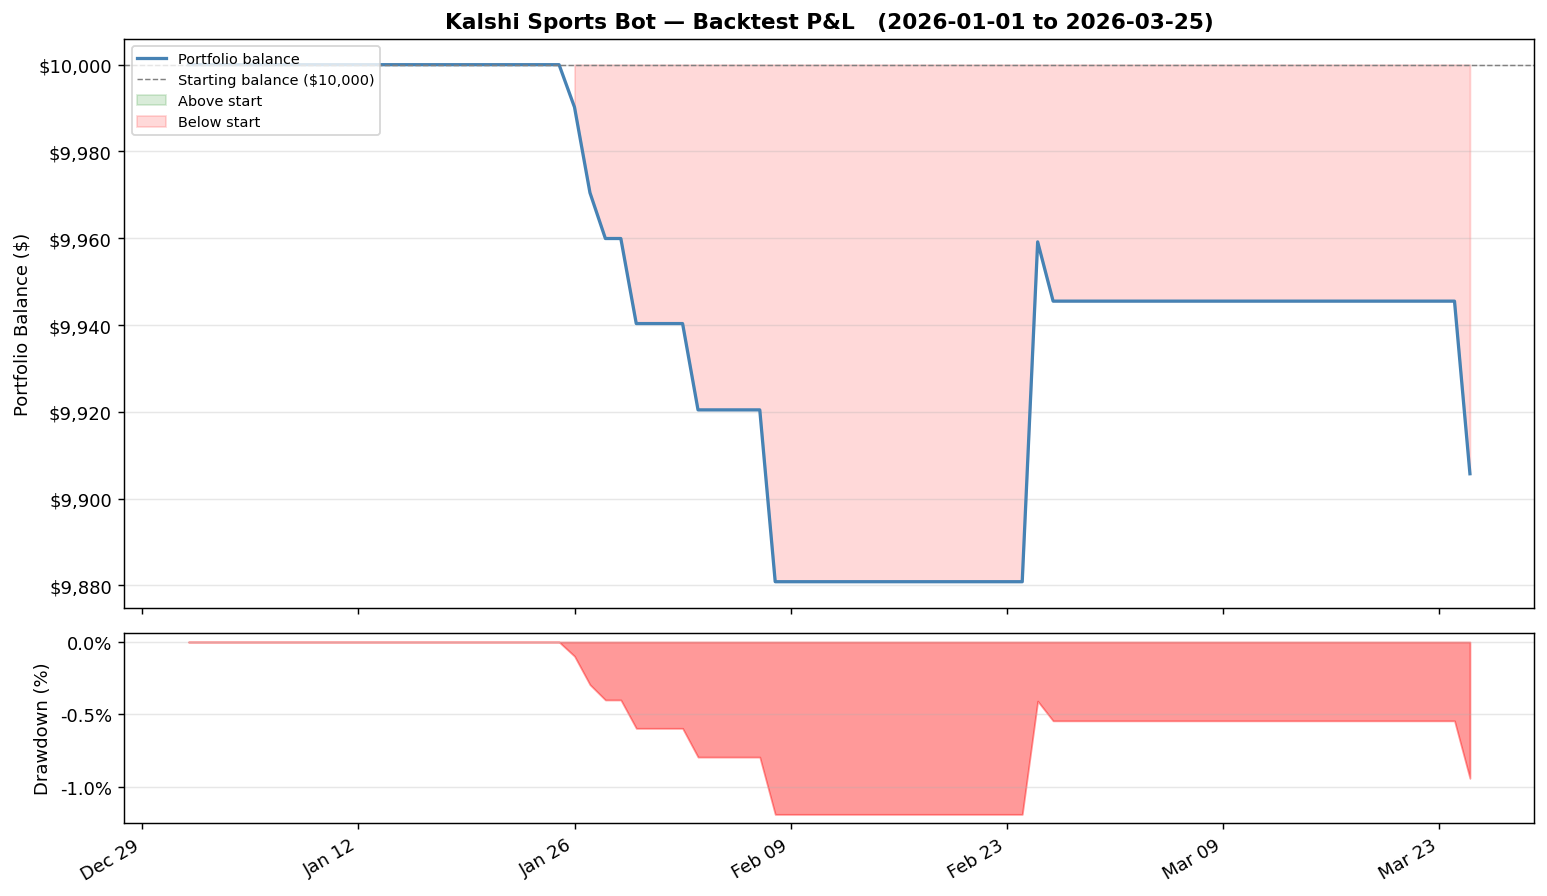

In [10]:
# ── Chart 1: Cumulative P&L ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7),
                          gridspec_kw={'height_ratios': [3, 1]},
                          sharex=True)

ax1, ax2 = axes

# Balance line
ax1.plot(bal_df['date'], bal_df['balance'], color='steelblue', linewidth=1.8, label='Portfolio balance')
ax1.axhline(STARTING_BALANCE, color='grey', linewidth=0.8, linestyle='--', label=f'Starting balance (${STARTING_BALANCE:,.0f})')
ax1.fill_between(bal_df['date'], STARTING_BALANCE, bal_df['balance'],
                  where=bal_df['balance'] >= STARTING_BALANCE,
                  alpha=0.15, color='green', label='Above start')
ax1.fill_between(bal_df['date'], STARTING_BALANCE, bal_df['balance'],
                  where=bal_df['balance'] < STARTING_BALANCE,
                  alpha=0.15, color='red', label='Below start')
ax1.set_ylabel('Portfolio Balance ($)')
ax1.set_title(f'Kalshi Sports Bot — Backtest P&L   ({BACKTEST_START} to {BACKTEST_END})',
               fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.grid(axis='y', alpha=0.3)

# Drawdown
ax2.fill_between(bal_df['date'], drawdown, 0, color='red', alpha=0.4)
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('backtest_pnl.png', dpi=130, bbox_inches='tight')
plt.show()

/var/folders/k1/1dqvw7750_b61hjyrl9b7zv80000gn/T/ipykernel_99871/277585451.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edge_grp = df.groupby(edge_bins).agg(


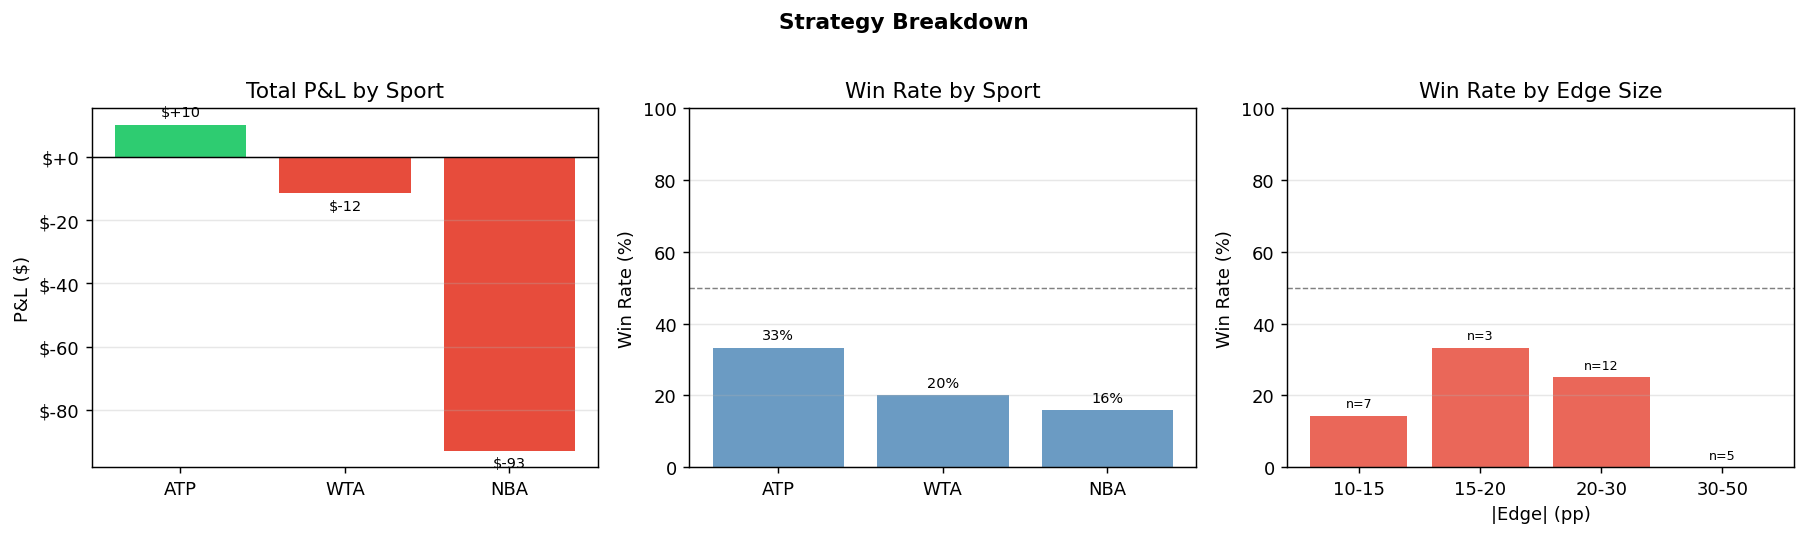


Per-sport summary:


,Trades,Wins,WinRate,TotalPnL,AvgPnL,AvgEdge
league,,,,,,
atp,3,1,33.0%,10.18,3.39,27.97
nba,19,3,16.0%,-92.90,-4.89,20.26
wta,5,1,20.0%,-11.55,-2.31,26.78


In [11]:
# ── Chart 2: Performance breakdown ────────────────────────────────────────────
if len(df) == 0:
    print('No trades to chart.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # 2a. P&L and win rate by sport/league
    ax = axes[0]
    sport_grp = df.groupby('league').agg(
        total_pnl=('pnl', 'sum'),
        n_trades =('pnl', 'count'),
        win_rate =('won', 'mean')
    ).sort_values('total_pnl', ascending=False)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sport_grp['total_pnl']]
    bars = ax.bar(sport_grp.index.str.upper(), sport_grp['total_pnl'], color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.bar_label(bars, fmt='${:+.0f}', padding=3, fontsize=8)
    ax.set_title('Total P&L by Sport')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+,.0f}'))
    ax.grid(axis='y', alpha=0.3)

    # 2b. Win rate by sport
    ax = axes[1]
    wr = sport_grp['win_rate'] * 100
    bars2 = ax.bar(wr.index.str.upper(), wr, color='steelblue', alpha=0.8)
    ax.axhline(50, color='grey', linewidth=0.8, linestyle='--', label='50%')
    ax.bar_label(bars2, fmt='%.0f%%', padding=3, fontsize=8)
    ax.set_title('Win Rate by Sport')
    ax.set_ylabel('Win Rate (%)')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

    # 2c. Edge size vs win rate (scatter with P&L encoded in colour)
    ax = axes[2]
    edge_bins = pd.cut(df['edge_pp'].abs(), bins=[10,15,20,30,50,100],
                        labels=['10-15','15-20','20-30','30-50','50+'])
    edge_grp = df.groupby(edge_bins).agg(
        win_rate=('won','mean'),
        n_trades=('won','count'),
        avg_pnl=('pnl','mean')
    ).dropna()
    colors3 = ['#2ecc71' if v >= 0 else '#e74c3c' for v in edge_grp['avg_pnl']]
    ax.bar(edge_grp.index.astype(str), edge_grp['win_rate']*100, color=colors3, alpha=0.85)
    ax.axhline(50, color='grey', linewidth=0.8, linestyle='--')
    for i, (idx, row) in enumerate(edge_grp.iterrows()):
        ax.text(i, row['win_rate']*100 + 1.5, f"n={int(row['n_trades'])}",
                ha='center', va='bottom', fontsize=7)
    ax.set_title('Win Rate by Edge Size')
    ax.set_xlabel('|Edge| (pp)')
    ax.set_ylabel('Win Rate (%)')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Strategy Breakdown', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('backtest_breakdown.png', dpi=130, bbox_inches='tight')
    plt.show()

    # Per-sport summary table
    print('\nPer-sport summary:')
    summary = df.groupby('league').agg(
        Trades   = ('pnl','count'),
        Wins     = ('won','sum'),
        WinRate  = ('won','mean'),
        TotalPnL = ('pnl','sum'),
        AvgPnL   = ('pnl','mean'),
        AvgEdge  = ('edge_pp', lambda x: x.abs().mean()),
    ).round(2)
    summary['WinRate'] = (summary['WinRate']*100).round(1).astype(str)+'%'
    display(summary)

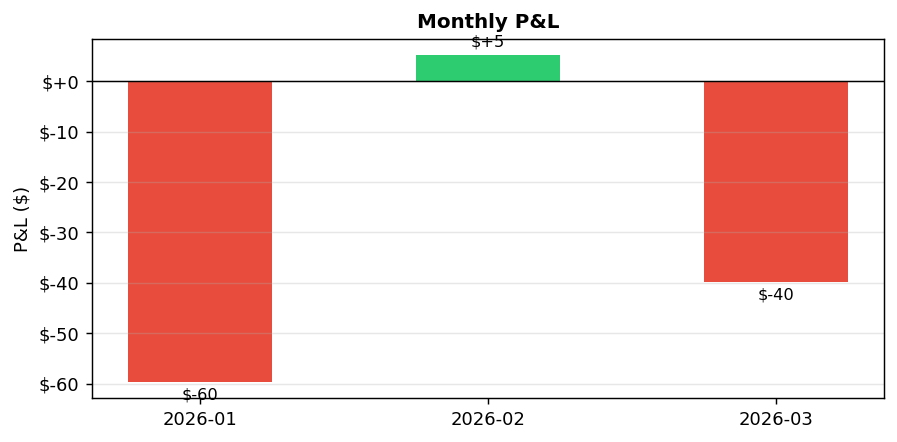

In [12]:
# ── Chart 3: Monthly P&L ──────────────────────────────────────────────────────
if len(df):
    df['month'] = pd.to_datetime(df['date']).dt.to_period('M').astype(str)
    monthly = df.groupby('month')['pnl'].sum()

    fig, ax = plt.subplots(figsize=(7, 3.5))
    colors_m = ['#2ecc71' if v >= 0 else '#e74c3c' for v in monthly]
    bars = ax.bar(monthly.index, monthly.values, color=colors_m, width=0.5)
    ax.bar_label(bars, fmt='${:+.0f}', padding=3, fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Monthly P&L', fontsize=11, fontweight='bold')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+,.0f}'))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('backtest_monthly.png', dpi=130, bbox_inches='tight')
    plt.show()

## Notes
- **Look-ahead risk (team records):** ESPN's historical scoreboard returns team records as of the game date, so this should be accurate. Verify spot-checks if precision matters.
- **Tennis rankings:** Current rankings are used as a proxy for all historical dates. Within a single season the impact is small but could distort early-season matches.
- **Fill assumption:** Trades are assumed to fill at the previous-day ask price. In practice, liquidity and spread conditions vary.
- **No transaction costs:** Kalshi charges no explicit commissions; the bid-ask spread is the only cost, which is partially captured by using the ask price.